In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv('real_estate_pca_200.csv')

print(data.shape)
data.head()

(200, 10)


,Property_ID,Price_Lakh,Bedrooms,Property_Age_Years,Distance_City_KM,Location_Score,Condition_Score,Amenities_Score,Days_On_Market,Sold_Within_6_Months
0,1,137,3,27,10.9,8.9,8.4,8.8,27,1
1,2,86,3,25,8.6,8.4,3.1,9.6,104,1
2,3,127,4,6,15.4,3.5,7.2,3.2,305,0
3,4,49,2,24,21.1,3.3,7.0,7.0,27,1
4,5,141,2,3,11.1,7.3,8.0,5.8,176,1


In [3]:
print(data.isnull().sum())

Property_ID             0
Price_Lakh              0
Bedrooms                0
Property_Age_Years      0
Distance_City_KM        0
Location_Score          0
Condition_Score         0
Amenities_Score         0
Days_On_Market          0
Sold_Within_6_Months    0
dtype: int64


In [4]:
features = [
    'Price_Lakh',
    'Bedrooms',
    'Property_Age_Years',
    'Distance_City_KM',
    'Location_Score',
    'Condition_Score',
    'Amenities_Score'
]

X = data[features]

print(X.head())

   Price_Lakh  Bedrooms  Property_Age_Years  Distance_City_KM  Location_Score  \
0         137         3                  27              10.9             8.9   
1          86         3                  25               8.6             8.4   
2         127         4                   6              15.4             3.5   
3          49         2                  24              21.1             3.3   
4         141         2                   3              11.1             7.3   

   Condition_Score  Amenities_Score  
0              8.4              8.8  
1              3.1              9.6  
2              7.2              3.2  
3              7.0              7.0  
4              8.0              5.8  


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(200, 7)


In [6]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (200, 3)


In [7]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.17644536 0.16317727 0.15502594]

Total Variance Explained:
0.4946485680155846


In [8]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=features
)

print(loadings)

                         PC1       PC2       PC3
Price_Lakh          0.002126 -0.211991  0.752600
Bedrooms           -0.001792  0.615751  0.089988
Property_Age_Years  0.658025 -0.052977 -0.021586
Distance_City_KM   -0.503700 -0.409172  0.118422
Location_Score     -0.094111  0.264471  0.587657
Condition_Score    -0.535398  0.129835 -0.251181
Amenities_Score     0.133317 -0.564694 -0.050718


In [9]:
for component in loadings.columns:
    print("\n", component)
    print(
        loadings[component]
        .abs()
        .sort_values(ascending=False)
    )


 PC1
Property_Age_Years    0.658025
Condition_Score       0.535398
Distance_City_KM      0.503700
Amenities_Score       0.133317
Location_Score        0.094111
Price_Lakh            0.002126
Bedrooms              0.001792
Name: PC1, dtype: float64

 PC2
Bedrooms              0.615751
Amenities_Score       0.564694
Distance_City_KM      0.409172
Location_Score        0.264471
Price_Lakh            0.211991
Condition_Score       0.129835
Property_Age_Years    0.052977
Name: PC2, dtype: float64

 PC3
Price_Lakh            0.752600
Location_Score        0.587657
Condition_Score       0.251181
Distance_City_KM      0.118422
Bedrooms              0.089988
Amenities_Score       0.050718
Property_Age_Years    0.021586
Name: PC3, dtype: float64


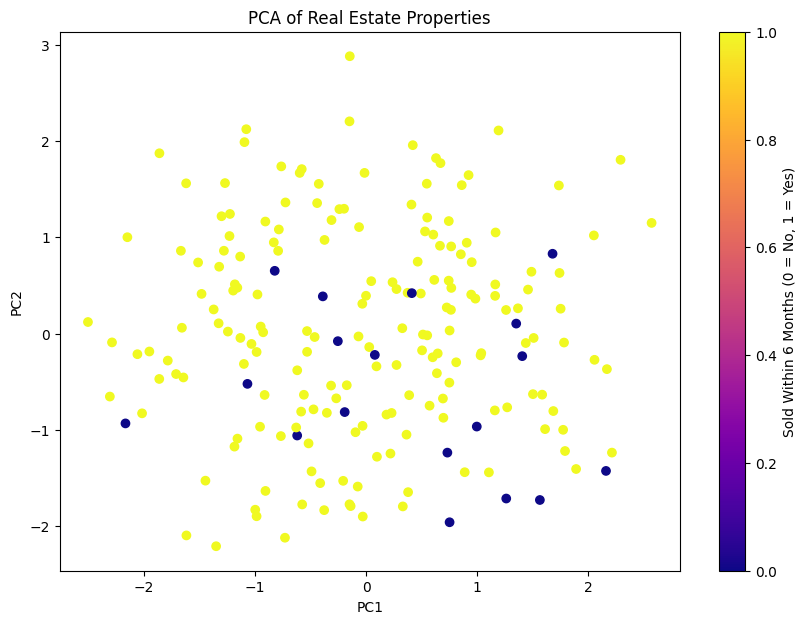

In [10]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=data['Sold_Within_6_Months'],
    cmap='plasma'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Real Estate Properties')

plt.colorbar(
    scatter,
    label='Sold Within 6 Months (0 = No, 1 = Yes)'
)

plt.show()